# Exploratory Data Analysis (EDA) for Fact-Check Dataset

## Victoria Knapp Perez and Jason LaRuez
Original data source: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

---
## Importing Necessary Packages

In [ ]:
# Importing data
import kagglehub
import os
import json

import matplotlib.pyplot as plt # Plotting
import pandas as pd # Pandas dataframes

from collections import Counter # For counting word occurrences
import string # string processing and tokenization

---
## Loading in dataset
### (The data consists of 8 json files containing 21,152 entires which we load into a pandas dataframe of size (21152 , 8) )

In [ ]:
# Download latest version of data
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

print("Path to dataset files:", path)

# List all files in the downloaded dataset directory
files = os.listdir(path)



Using Colab cache for faster access to the 'fake-news-classification' dataset.
Path to dataset files: /kaggle/input/fake-news-classification


In [ ]:
news_file = os.path.join(path, "WELFake_Dataset.csv")

df_news = pd.read_csv(news_file) #Load data from csv to pd

In [ ]:
df_news.head(3)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


In [ ]:
# Count rows with at least one NaN in any column
num_nan_rows = df_news.isna().any(axis=1).sum()

We then filter these samples where there is a 'nan in at least on of the columns

In [ ]:
# Get all rows that contain at least one NaN
df_news_nonnan = df_news[~df_news.isna().any(axis=1)]


---
First we look at the distribution of true (1) vs. fake (0) news

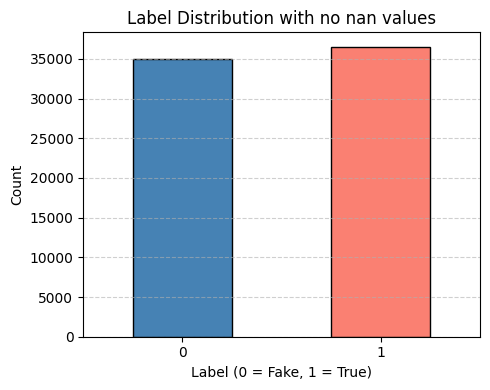

In [ ]:
# Make an explicit copy first
df_news_nonnan2 = df_news_nonnan.copy()

# Then safely modify the column
df_news_nonnan2['label'] = df_news_nonnan2['label'].astype(int)


# Plot histogram / bar chart
plt.figure(figsize=(5,4))
df_news_nonnan2['label'].value_counts().sort_index().plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black'
)
plt.title('Label Distribution with no nan values')
plt.xlabel('Label (0 = Fake, 1 = True)')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
def clean_and_tokenize(text):
    """Removes punctuation, converts to lowercase, and tokenizes text."""
    if isinstance(text, str):
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = text.lower()
        return text.split()
    return [] # Return empty list for non-string inputs

In [ ]:
# list of "stop words" from NLTK: These are worse which are considered not to have much value in NLP
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself",
              "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
              "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
              "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
              "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because",
              "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into",
              "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out",
              "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where",
              "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no",
              "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just",
              "don", "should", "now"]

word_frequencies_per_statement_by_label = {}

unique_labels= df_news_nonnan2['label'].unique()
df_by_label = {}

for label in unique_labels:
    df_by_label[label] = df_news_nonnan2[df_news_nonnan2['label'] == label].copy()

for label, df_subset in df_by_label.items():
    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['text'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Calculate word frequencies
    word_frequencies = Counter(all_words)

    # Calculate frequency per statement
    num_statements = df_subset.shape[0]
    word_frequencies_per_statement = {word: int(freq) for word, freq in word_frequencies.items()}

    word_frequencies_per_statement_by_label[label] = word_frequencies_per_statement

# Display the number of unique words found for each verdict
for label, frequencies in word_frequencies_per_statement_by_label.items():
    print(f"Verdict '{label}': {len(frequencies)} unique words")

Verdict '1': 335098 unique words
Verdict '0': 199750 unique words


In [ ]:
# Define how many of the most frequent words to display
top_n = 10

for label, frequencies in word_frequencies_per_statement_by_label.items():
    print(f"\nTop {top_n} most frequent words for verdict '{label}':")
    # Since 'frequencies' is now a dictionary, convert it to a Counter for most_common()
    word_frequencies_counter = Counter(frequencies)
    for word, frequency in word_frequencies_counter.most_common(top_n):
        print(f"- {word}: {frequency}") # Format to 4 decimal places for readability


Top 10 most frequent words for verdict '1':
- trump: 95575
- us: 48562
- said: 46758
- people: 46430
- would: 42641
- one: 42458
- clinton: 39249
- president: 35420
- like: 30636
- hillary: 28848

Top 10 most frequent words for verdict '0':
- said: 184476
- trump: 82440
- mr: 65775
- would: 62032
- us: 51420
- ”: 46384
- president: 46351
- —: 45764
- new: 42082
- one: 40438


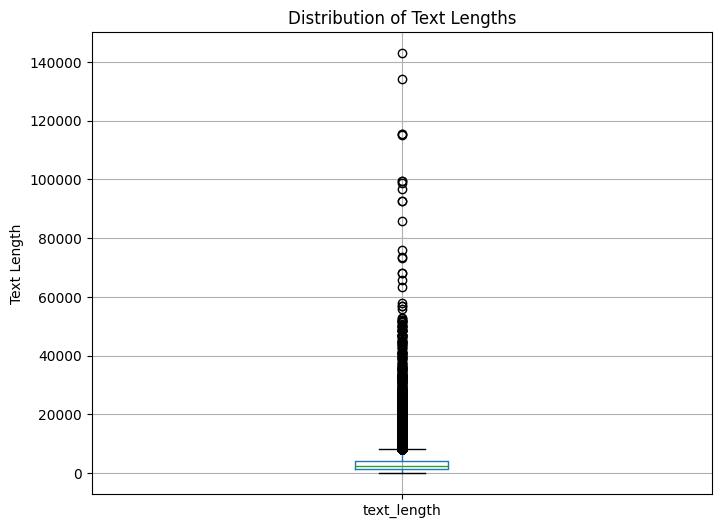

In [ ]:
df_news_nonnan2['text_length'] = df_news_nonnan2['text'].apply(len)

plt.figure(figsize=(8, 6))
df_news_nonnan2.boxplot(column='text_length')
plt.title('Distribution of Text Lengths')
plt.ylabel('Text Length')
plt.show()

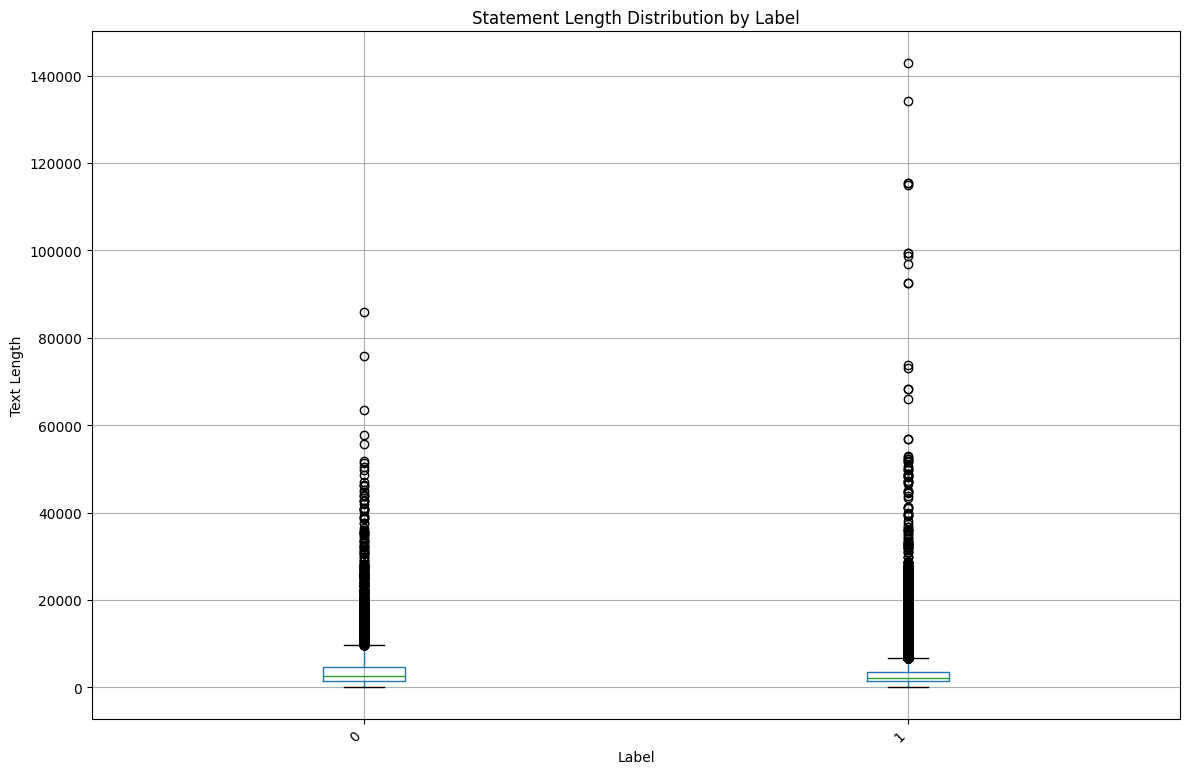

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
df_news_nonnan2.boxplot(column='text_length', by='label', ax=ax)
ax.set_title('Statement Length Distribution by Label')
ax.set_xlabel('Label')
ax.set_ylabel('Text Length')
plt.xticks(rotation=45, ha='right')
fig.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
def calculate_stop_word_proportion(text):
    """Calculates the proportion of stop words in a text."""
    tokens = clean_and_tokenize(text)
    total_words = len(tokens)
    if total_words == 0:
        return 0
    stop_word_count = sum(1 for word in tokens if word in stop_words)
    return stop_word_count / total_words

df_news_nonnan2['stop_word_proportion'] = df_news_nonnan2['text'].apply(calculate_stop_word_proportion)

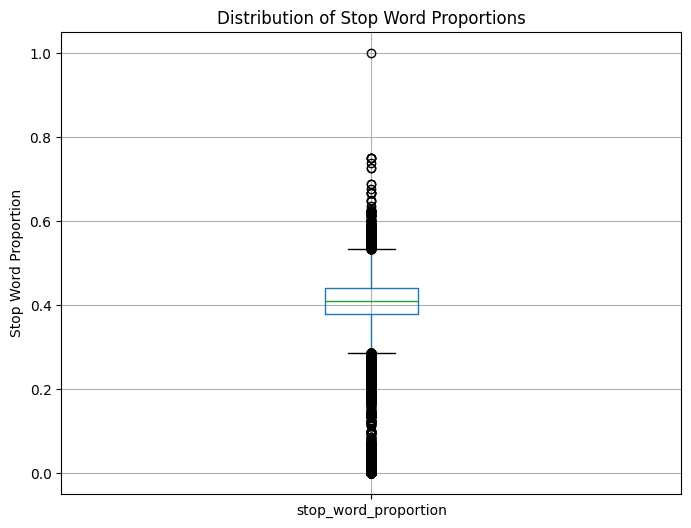

In [ ]:
plt.figure(figsize=(8, 6))
df_news_nonnan2.boxplot(column='stop_word_proportion')
plt.title('Distribution of Stop Word Proportions')
plt.ylabel('Stop Word Proportion')
plt.show()

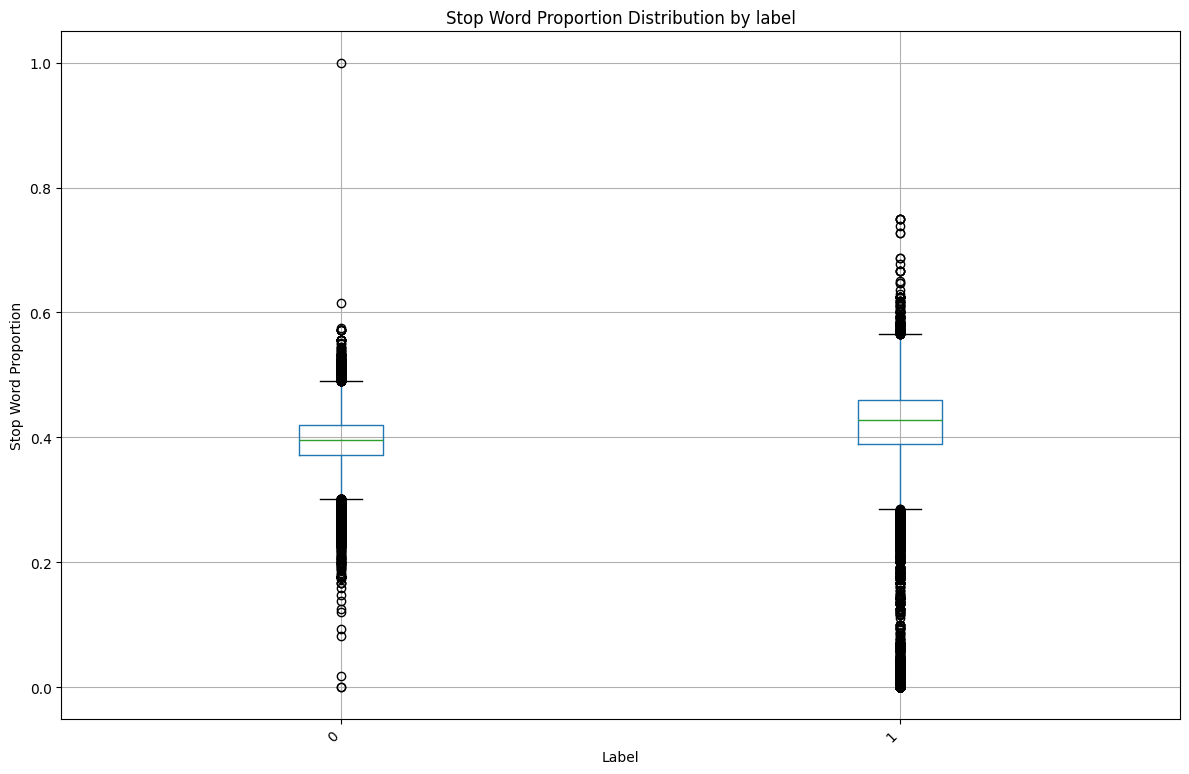

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
df_news_nonnan2.boxplot(column='stop_word_proportion', by='label', ax=ax)
ax.set_title('Stop Word Proportion Distribution by label')
ax.set_xlabel('Label')
ax.set_ylabel('Stop Word Proportion')
plt.xticks(rotation=45, ha='right')
fig.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
def generate_ngrams(tokens, n):
    """Generates n-grams from a list of tokens."""
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngrams.append(tuple(tokens[i:i+n]))
    return ngrams

In [ ]:
# Apply the clean_and_tokenize function to the 'statement' column for the entire dataframe
tokenized_statements_all = df_news_nonnan2['text'].apply(clean_and_tokenize)

# Flatten the list of lists into a single list of words, excluding stop words
all_words_cleaned = [word for tokens in tokenized_statements_all for word in tokens if word not in stop_words]

# Generate bigrams and trigrams
bigrams_all = generate_ngrams(all_words_cleaned, 2)
trigrams_all = generate_ngrams(all_words_cleaned, 3)

# Count the occurrences of each bigram and trigram
bigram_counts_all = Counter(bigrams_all)
trigram_counts_all = Counter(trigrams_all)

# Display the number of unique bigrams and trigrams found
print(f"Number of unique bigrams in the entire dataset: {len(bigram_counts_all)}")
print(f"Number of unique trigrams in the entire dataset: {len(trigram_counts_all)}")

Number of unique bigrams in the entire dataset: 8643968
Number of unique trigrams in the entire dataset: 16330168


In [ ]:
bigram_counts_by_label = {}
trigram_counts_by_label = {}

for label in unique_labels:
    df_subset = df_by_label[label]

    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['text'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words, excluding stop words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Generate bigrams and trigrams
    bigrams = generate_ngrams(all_words, 2)
    trigrams = generate_ngrams(all_words, 3)

    # Count the occurrences of each bigram and trigram
    bigram_counts_by_label[label] = Counter(bigrams)
    trigram_counts_by_label[label] = Counter(trigrams)

    # Print the number of unique bigrams and trigrams found for each label
    print(f"Label '{label}': {len(bigram_counts_by_label[label])} unique bigrams, {len(trigram_counts_by_label[label])} unique trigrams")

Label '1': 4219219 unique bigrams, 6722565 unique trigrams
Label '0': 5432660 unique bigrams, 9926543 unique trigrams


In [ ]:
# Print top n-grams for the entire dataset
top_n_all = 20
print(f"Top {top_n_all} most frequent bigrams for the entire dataset:")
for bigram, count in bigram_counts_all.most_common(top_n_all):
    print(f"- {bigram}: {count}")

print(f"\nTop {top_n_all} most frequent trigrams for the entire dataset:")
for trigram, count in trigram_counts_all.most_common(top_n_all):
    print(f"- {trigram}: {count}")

# Print top n-grams for each label
top_n_label = 10
for label, bigram_counts in bigram_counts_by_label.items():
    print(f"\nTop {top_n_label} most frequent bigrams for label '{label}':")
    for bigram, count in bigram_counts.most_common(top_n_label):
        print(f"- {bigram}: {count}")

for label, trigram_counts in trigram_counts_by_label.items():
    print(f"\nTop {top_n_label} most frequent trigrams for label '{label}':")
    for trigram, count in trigram_counts.most_common(top_n_label):
        print(f"- {trigram}: {count}")



Top 20 most frequent bigrams for the entire dataset:
- ('united', 'states'): 32703
- ('donald', 'trump'): 30309
- ('white', 'house'): 22665
- ('hillary', 'clinton'): 19102
- ('new', 'york'): 18880
- ('mr', 'trump'): 13737
- ('president', 'donald'): 8159
- ('last', 'year'): 8044
- ('last', 'week'): 7443
- ('trump', 'said'): 7277
- ('north', 'korea'): 7169
- ('prime', 'minister'): 6796
- ('secretary', 'state'): 6787
- ('islamic', 'state'): 6778
- ('barack', 'obama'): 6743
- ('supreme', 'court'): 6692
- ('president', 'obama'): 6622
- ('washington', 'reuters'): 6488
- ('image', 'via'): 6391
- ('national', 'security'): 6332

Top 20 most frequent trigrams for the entire dataset:
- ('president', 'donald', 'trump'): 6095
- ('new', 'york', 'times'): 5177
- ('donald', 'j', 'trump'): 3744
- ('president', 'barack', 'obama'): 3696
- ('us', 'president', 'donald'): 2610
- ('washington', 'reuters', 'us'): 2351
- ('george', 'w', 'bush'): 2225
- ('new', 'york', 'city'): 2010
- ('21st', 'century', 'wire'

In [ ]:
for label, trigram_counts in trigram_counts_by_label.items():
    print(f"\nTop {top_n_label} most frequent trigrams for verdict '{label}':")
    for trigram, count in trigram_counts.most_common(top_n_label):
        print(f"- {trigram}: {count}")



Top 10 most frequent trigrams for verdict '1':
- ('new', 'york', 'times'): 2443
- ('donald', 'j', 'trump'): 2309
- ('21st', 'century', 'wire'): 1932
- ('j', 'trump', 'realdonaldtrump'): 1731
- ('black', 'lives', 'matter'): 1504
- ('president', 'united', 'states'): 1321
- ('president', 'barack', 'obama'): 1134
- ('fbi', 'director', 'james'): 1018
- ('news', '21st', 'century'): 978
- ('george', 'w', 'bush'): 930

Top 10 most frequent trigrams for verdict '0':
- ('president', 'donald', 'trump'): 5162
- ('new', 'york', 'times'): 2734
- ('president', 'barack', 'obama'): 2562
- ('us', 'president', 'donald'): 2550
- ('washington', 'reuters', 'us'): 2351
- ('president', 'donald', 'trump’s'): 1785
- ('donald', 'j', 'trump'): 1435
- ('george', 'w', 'bush'): 1295
- ('new', 'york', 'city'): 1154
- ('affordable', 'care', 'act'): 1121
